# Quantum Finance — Credit Scoring

Comparação entre **Regressão Linear** e **Árvore de Regressão** para previsão do `SCORE_CREDITO`.

**Estrutura:**
- Parte 1 — Leitura + EDA
- Parte 2 — Correlação
- Parte 3 — Modelagem (Linear vs. Árvore) + Simulador

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)

## Parte 1 — Leitura e EDA

In [3]:
# decimal="," resolve SCORE_CREDITO e vl_salario_mil na leitura,
# sem precisar de str.replace coluna a coluna.
# O CSV deve estar na mesma pasta do notebook.
df = pd.read_csv(
    "Base_ScoreCredito_QuantumFinance(8).csv",
    sep=";",
    decimal=","
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10127 non-null  int64  
 1   idade                10127 non-null  int64  
 2   sexo                 10127 non-null  str    
 3   estado_civil         10127 non-null  str    
 4   escola               10127 non-null  str    
 5   Qte_dependentes      10127 non-null  int64  
 6   tempo_ultimoservico  10127 non-null  int64  
 7   trabalha             10127 non-null  int64  
 8   vl_salario_mil       10127 non-null  float64
 9   reg_moradia          10127 non-null  int64  
 10  casa_propria         10127 non-null  int64  
 11  vl_imovel_em_mil     10127 non-null  int64  
 12  Qte_cartoes          10127 non-null  int64  
 13  Qte_carros           10127 non-null  int64  
 14  SCORE_CREDITO        10127 non-null  float64
dtypes: float64(2), int64(10), str(3)
memory usage: 

In [4]:
df.describe(include="all")

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,1.012700e+04,10127.000000,10127,10127,10127,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,NaN,NaN,2,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,F,casado,ensino medio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5358,4687,3352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.391776e+08,46.325960,NaN,NaN,NaN,1.547447,34.133208,0.911919,70.209002,3.783450,0.352424,208.999111,1.083638,0.623383,469.500364
std,3.690378e+07,8.016814,NaN,NaN,NaN,1.489079,8.221428,0.283427,55.567032,1.580486,0.477749,378.495229,0.333784,0.569796,133.814653
min,7.080821e+08,26.000000,NaN,NaN,NaN,0.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,162.000000
25%,7.130368e+08,41.000000,NaN,NaN,NaN,0.000000,30.000000,1.000000,21.330536,3.000000,0.000000,0.000000,1.000000,0.000000,375.000000
50%,7.179264e+08,46.000000,NaN,NaN,NaN,1.000000,34.000000,1.000000,66.486331,4.000000,0.000000,0.000000,1.000000,1.000000,449.600000
75%,7.731435e+08,52.000000,NaN,NaN,NaN,3.000000,39.000000,1.000000,107.544225,5.000000,1.000000,289.000000,1.000000,1.000000,540.900000


In [5]:
# Verificacao de nulos
print("Valores nulos por coluna:")
print(df.isna().sum().sort_values(ascending=False))

Valores nulos por coluna:
id                     0
idade                  0
sexo                   0
estado_civil           0
escola                 0
Qte_dependentes        0
tempo_ultimoservico    0
trabalha               0
vl_salario_mil         0
reg_moradia            0
casa_propria           0
vl_imovel_em_mil       0
Qte_cartoes            0
Qte_carros             0
SCORE_CREDITO          0
dtype: int64


In [6]:
# Zeros em vl_imovel (justifica usar log1p em vez de log)
print("Zeros em vl_imovel_em_mil:",
      (df["vl_imovel_em_mil"] == 0).sum(),
      f"({(df['vl_imovel_em_mil'] == 0).mean() * 100:.1f}% da base)")

Zeros em vl_imovel_em_mil: 6558 (64.8% da base)


### Distribuição das variáveis quantitativas

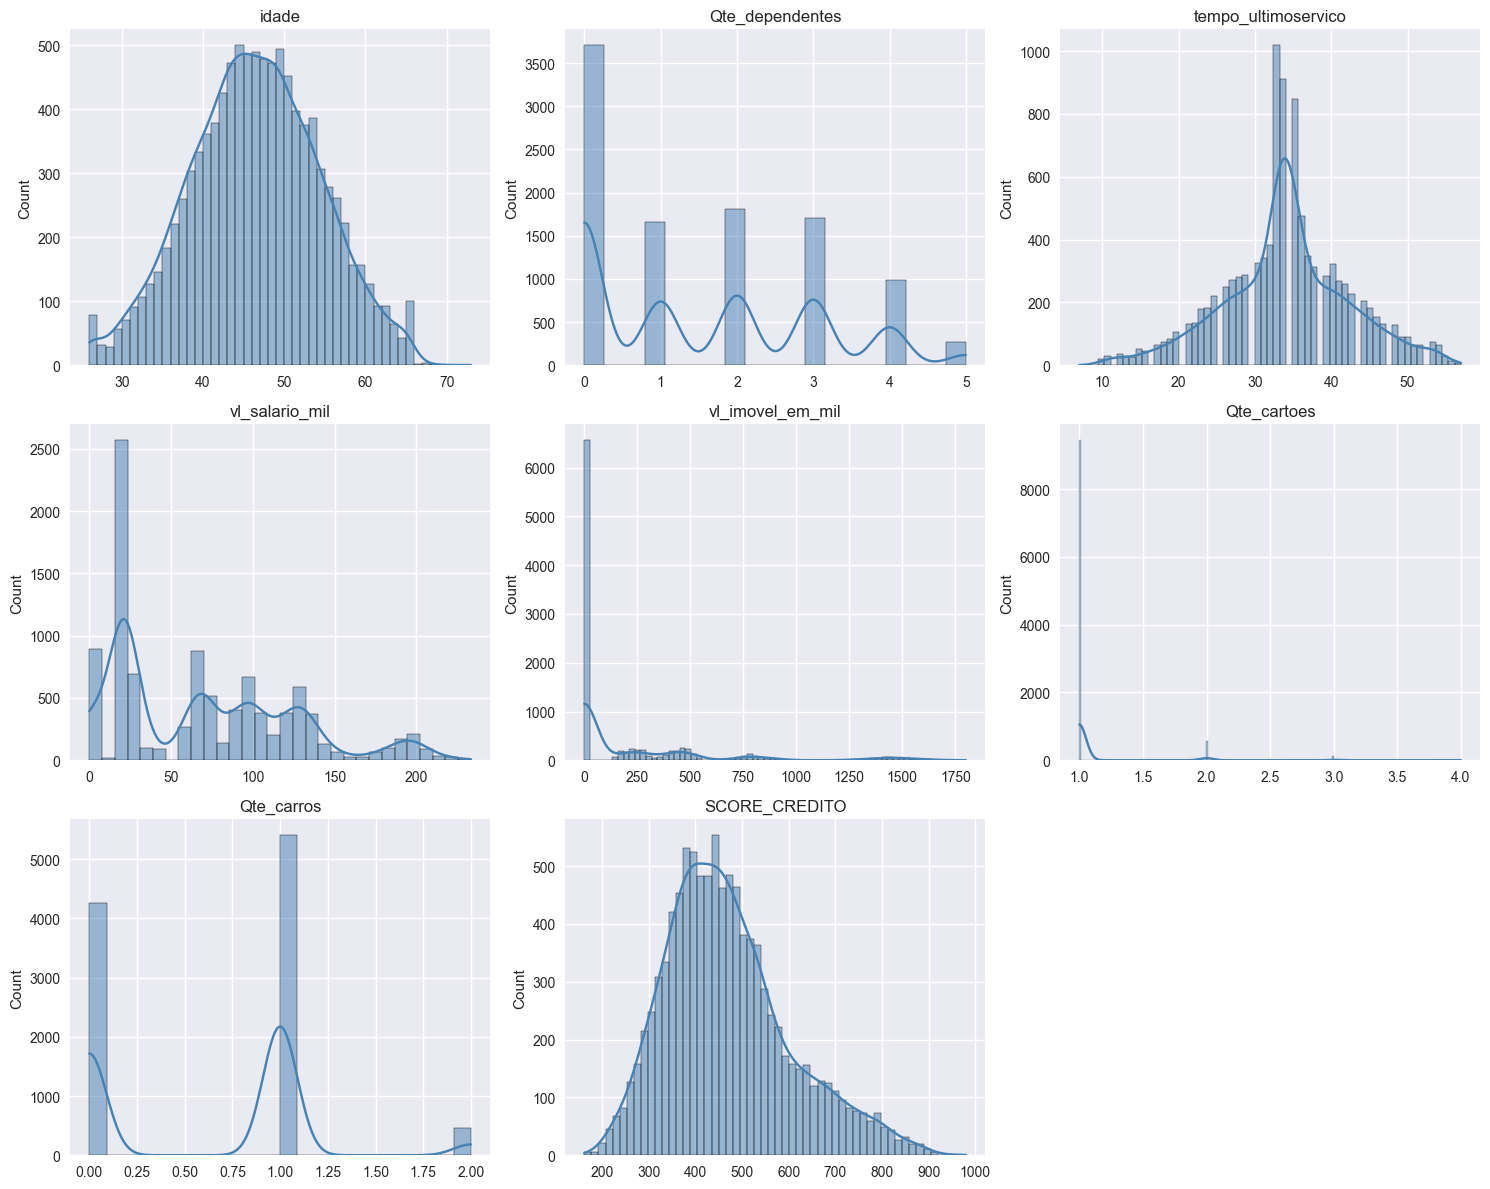

In [7]:
quantitativas = [
    "idade", "Qte_dependentes", "tempo_ultimoservico",
    "vl_salario_mil", "vl_imovel_em_mil",
    "Qte_cartoes", "Qte_carros", "SCORE_CREDITO"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(quantitativas):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplots (outliers)

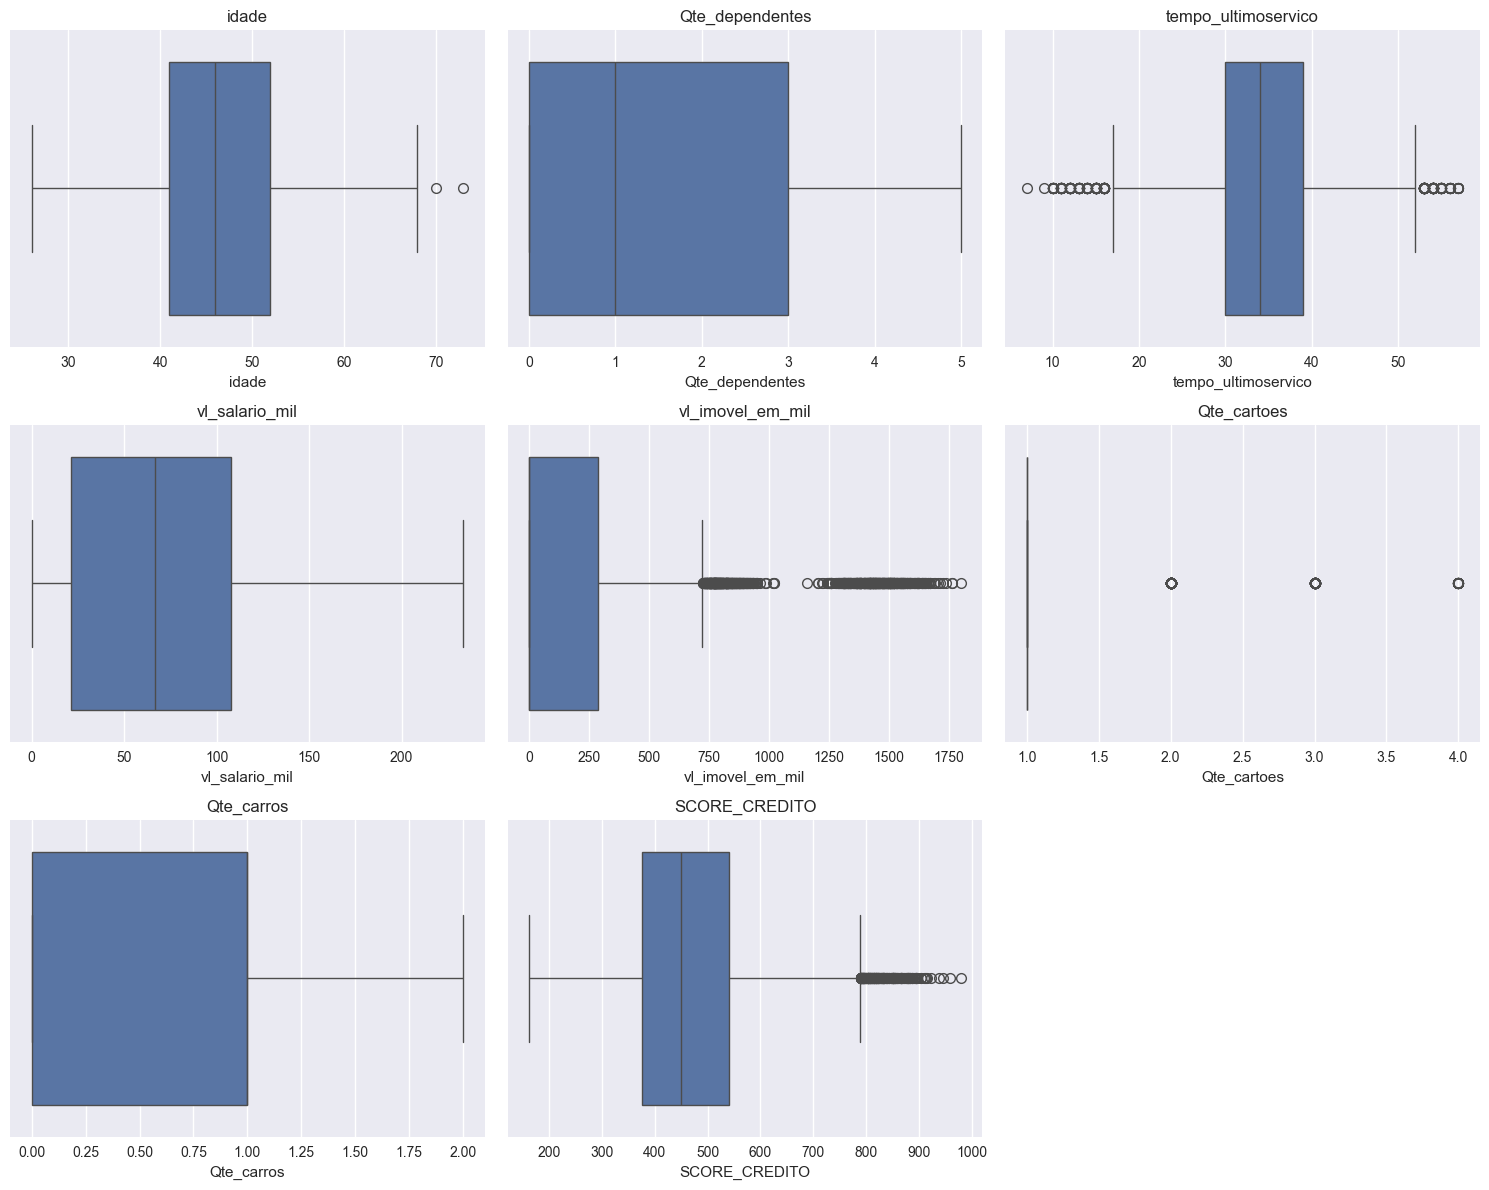

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(quantitativas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [9]:
# Contagem de outliers moderados e extremos via IQR
for col in ["vl_imovel_em_mil", "tempo_ultimoservico", "SCORE_CREDITO"]:
    Q1, Q3 = np.percentile(df[col], [25, 75])
    IQ = Q3 - Q1

    lim_15_sup, lim_3_sup = Q3 + 1.5 * IQ, Q3 + 3 * IQ
    lim_15_inf, lim_3_inf = Q1 - 1.5 * IQ, Q1 - 3 * IQ

    mod_sup = ((df[col] > lim_15_sup) & (df[col] <= lim_3_sup)).sum()
    ext_sup = (df[col] > lim_3_sup).sum()
    mod_inf = ((df[col] < lim_15_inf) & (df[col] >= lim_3_inf)).sum()
    ext_inf = (df[col] < lim_3_inf).sum()

    print(f"\n{col}:")
    print(f"  Superiores -> moderados: {mod_sup}, extremos: {ext_sup}")
    print(f"  Inferiores -> moderados: {mod_inf}, extremos: {ext_inf}")
    print(f"  TOTAL outliers (1.5xIQR): {mod_sup + ext_sup + mod_inf + ext_inf}")


vl_imovel_em_mil:
  Superiores -> moderados: 533, extremos: 562
  Inferiores -> moderados: 0, extremos: 0
  TOTAL outliers (1.5xIQR): 1095

tempo_ultimoservico:
  Superiores -> moderados: 187, extremos: 0
  Inferiores -> moderados: 240, extremos: 0
  TOTAL outliers (1.5xIQR): 427

SCORE_CREDITO:
  Superiores -> moderados: 248, extremos: 0
  Inferiores -> moderados: 0, extremos: 0
  TOTAL outliers (1.5xIQR): 248


### Contagem das variáveis qualitativas

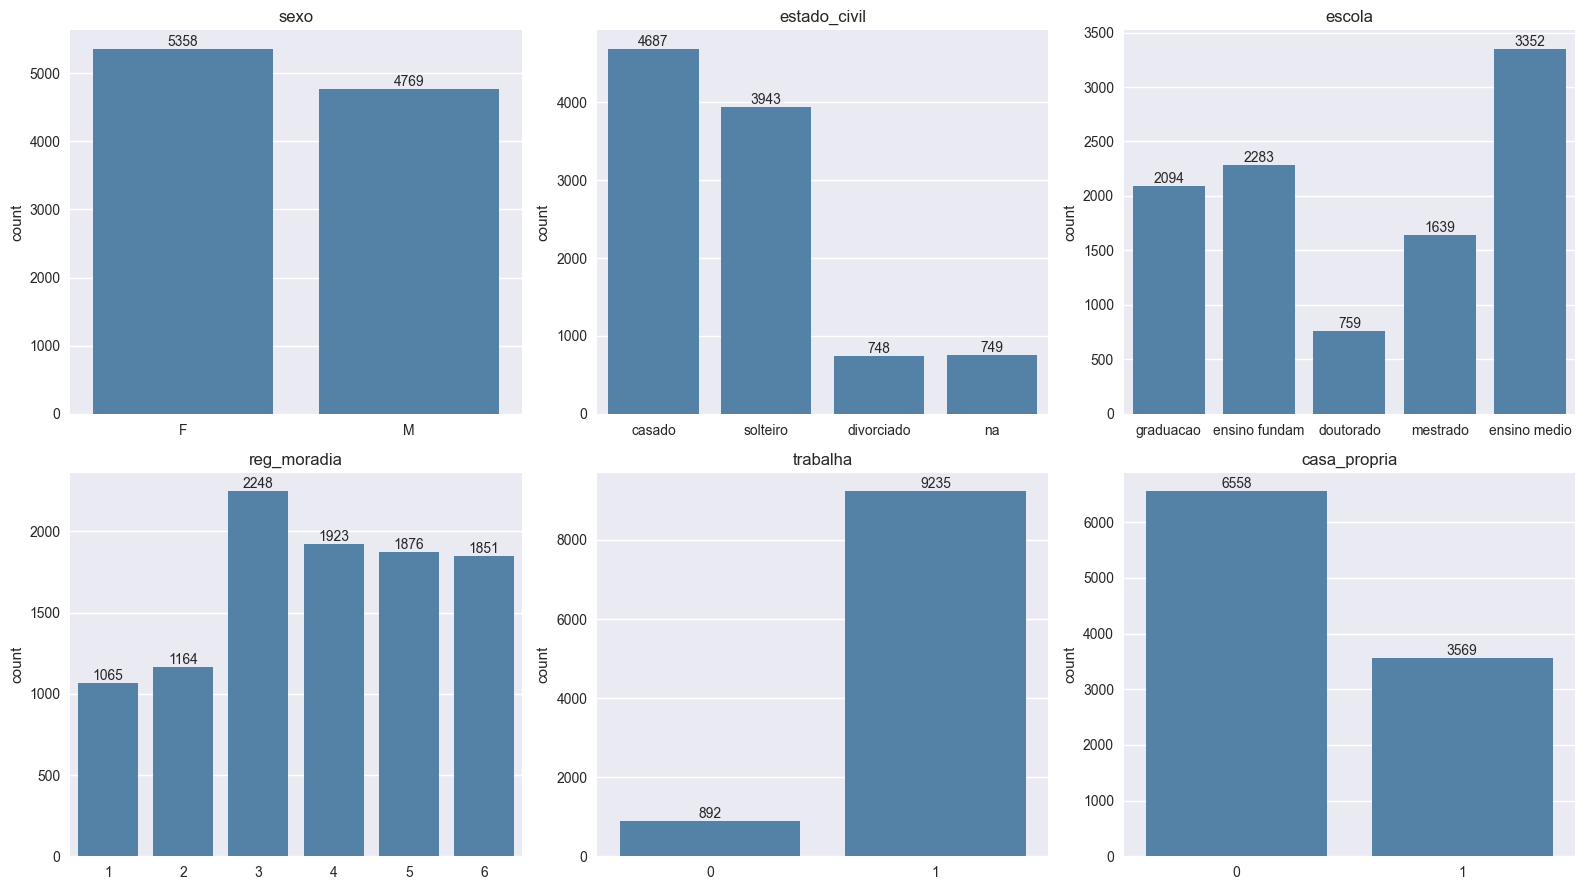

In [10]:
categoricas = ["sexo", "estado_civil", "escola",
               "reg_moradia", "trabalha", "casa_propria"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df, x=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    for container in axes[i].containers:
        axes[i].bar_label(container)

plt.tight_layout()
plt.show()

### Tratamentos

- `'na'` em `estado_civil` vira a categoria `'nao_informado'` (excluir seria perda relevante de amostra)
- `vl_imovel_em_mil` tem alta assimetria e muitos zeros → transformação `log1p`

In [11]:
pct_na = (df["estado_civil"] == "na").mean() * 100
print(f"'na' em estado_civil: {pct_na:.1f}% da base -> vira 'nao_informado'")

df["estado_civil"] = df["estado_civil"].replace("na", "nao_informado")

print("Assimetria vl_imovel_em_mil:", round(df["vl_imovel_em_mil"].skew(), 2))
df["vl_imovel_log"] = np.log1p(df["vl_imovel_em_mil"])

'na' em estado_civil: 7.4% da base -> vira 'nao_informado'
Assimetria vl_imovel_em_mil: 2.18


## Parte 2 — Correlação

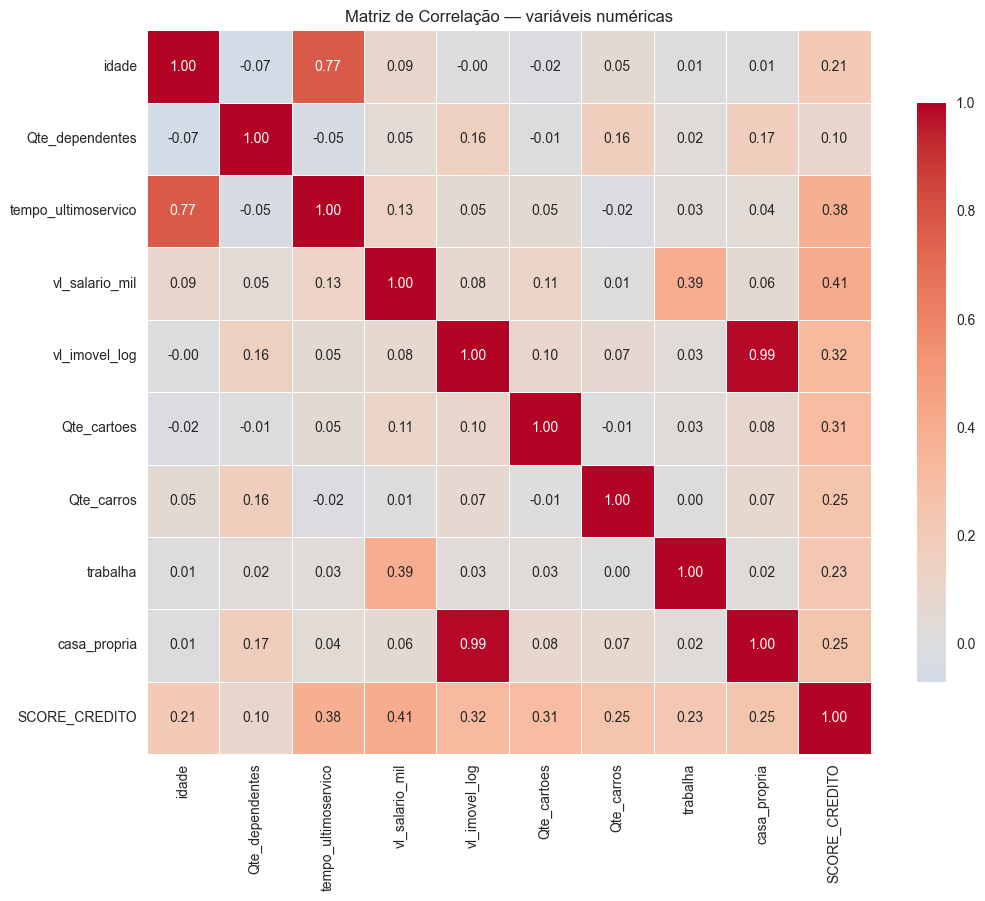

In [12]:
num_corr = ["idade", "Qte_dependentes", "tempo_ultimoservico",
            "vl_salario_mil", "vl_imovel_log", "Qte_cartoes",
            "Qte_carros", "trabalha", "casa_propria", "SCORE_CREDITO"]

corr = df[num_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlação — variáveis numéricas")
plt.tight_layout()
plt.show()

In [13]:
# Score medio por categoria
for col in ["sexo", "estado_civil", "escola", "reg_moradia"]:
    print(f"\n=== SCORE medio por {col} ===")
    print(df.groupby(col)["SCORE_CREDITO"].mean().sort_values())


=== SCORE medio por sexo ===
sexo
F    442.007309
M    500.388976
Name: SCORE_CREDITO, dtype: float64

=== SCORE medio por estado_civil ===
estado_civil
solteiro         450.747539
casado           476.336147
divorciado       494.775869
nao_informado    500.203965
Name: SCORE_CREDITO, dtype: float64

=== SCORE medio por escola ===
escola
ensino fundam    429.601743
graduacao        471.991681
ensino medio     477.587918
mestrado         486.558557
doutorado        510.085178
Name: SCORE_CREDITO, dtype: float64

=== SCORE medio por reg_moradia ===
reg_moradia
5    439.355034
6    439.872176
4    440.864552
3    453.724560
2    530.968588
1    591.919213
Name: SCORE_CREDITO, dtype: float64


## Parte 3 — Modelagem

Pré-processamento via `Pipeline` + `ColumnTransformer`: os encoders são ajustados **apenas no treino**, evitando vazamento de dados.
`vl_imovel_em_mil` sai do modelo (substituída pela versão log).

In [14]:
X = df.drop(columns=["id", "SCORE_CREDITO", "vl_imovel_em_mil"])
y = df["SCORE_CREDITO"]

cat_nominais = ["sexo", "estado_civil", "reg_moradia"]
cat_ordinais = ["escola"]
numericas = [c for c in X.columns if c not in cat_nominais + cat_ordinais]

ordem_escola = [["ensino fundam", "ensino medio", "graduacao",
                 "mestrado", "doutorado"]]

preprocessador = ColumnTransformer([
    ("num", "passthrough", numericas),
    ("ord", OrdinalEncoder(categories=ordem_escola), cat_ordinais),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_nominais)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")

Treino: 8101 | Teste: 2026


### Modelo 1 — Regressão Linear

In [15]:
modelo_lr = Pipeline([
    ("prep", preprocessador),
    ("modelo", LinearRegression())
])

modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

print("R²   :", round(r2_score(y_test, pred_lr), 4))
print("RMSE :", round(root_mean_squared_error(y_test, pred_lr), 2))
print("MAE  :", round(mean_absolute_error(y_test, pred_lr), 2))

R²   : 0.6203
RMSE : 81.57
MAE  : 62.32


### Summary (statsmodels)

Ajustado **apenas no treino**, usando o mesmo preprocessador já fitado do pipeline — coeficientes consistentes com as métricas de teste acima.

In [16]:
prep_fitted = modelo_lr.named_steps["prep"]  # ja fitado no treino

X_train_sm = pd.DataFrame(
    prep_fitted.transform(X_train),
    columns=prep_fitted.get_feature_names_out(),
    index=X_train.index
)
X_train_sm = sm.add_constant(X_train_sm)

modelo_stats = sm.OLS(y_train, X_train_sm).fit()
print(modelo_stats.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     859.4
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:39:24   Log-Likelihood:                -46705.
No. Observations:                8101   AIC:                         9.345e+04
Df Residuals:                    8081   BIC:                         9.359e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

### VIF (multicolinearidade)

`casa_propria` e `vl_imovel_log` apresentam VIF elevado (~70+) porque são quase redundantes (sem casa própria → imóvel = 0). Mantivemos ambas por melhorarem a capacidade **preditiva**, mas os coeficientes individuais dessas duas devem ser interpretados com cautela — o cenário alternativo abaixo quantifica o trade-off.

In [17]:
vif = pd.DataFrame({
    "Variavel": X_train_sm.columns,
    "VIF": [variance_inflation_factor(X_train_sm.values, i)
            for i in range(X_train_sm.shape[1])]
})

vif.sort_values("VIF", ascending=False)

,Variavel,VIF
0,const,114.910207
9,num__vl_imovel_log,78.255933
6,num__casa_propria,72.570117
17,cat__reg_moradia_4,6.280673
18,cat__reg_moradia_5,6.232473
19,cat__reg_moradia_6,6.195980
16,cat__reg_moradia_3,3.880640
5,num__vl_salario_mil,2.638298
3,num__tempo_ultimoservico,2.619231
1,num__idade,2.614991


In [18]:
# Cenario alternativo: sem casa_propria (menos colinearidade)
modelo_lr_sem = Pipeline([
    ("prep", ColumnTransformer([
        ("num", "passthrough", [c for c in numericas if c != "casa_propria"]),
        ("ord", OrdinalEncoder(categories=ordem_escola), cat_ordinais),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_nominais)
    ])),
    ("modelo", LinearRegression())
])

modelo_lr_sem.fit(X_train.drop(columns="casa_propria"), y_train)
pred_lr_sem = modelo_lr_sem.predict(X_test.drop(columns="casa_propria"))

print("===== LINEAR SEM casa_propria =====")
print("R²   :", round(r2_score(y_test, pred_lr_sem), 4))
print("RMSE :", round(root_mean_squared_error(y_test, pred_lr_sem), 2))

===== LINEAR SEM casa_propria =====
R²   : 0.4694
RMSE : 96.43


### Modelo 2 — Árvore de Regressão

Tuning da profundidade comparando R² de treino vs. teste, para justificar a poda:
- Sem limite: R² treino ≈ 1,0 e teste bem menor → **overfitting** clássico
- `max_depth=8` entrega o melhor equilíbrio (maior R² de teste com gap treino-teste ainda controlado)

In [19]:
print(f"{'depth':>6} {'R2 treino':>10} {'R2 teste':>10}")

for depth in [3, 4, 5, 6, 8, 10, None]:
    arv = Pipeline([
        ("prep", preprocessador),
        ("modelo", DecisionTreeRegressor(random_state=42, max_depth=depth))
    ])
    arv.fit(X_train, y_train)
    r2_tr = r2_score(y_train, arv.predict(X_train))
    r2_te = r2_score(y_test, arv.predict(X_test))
    print(f"{str(depth):>6} {r2_tr:>10.4f} {r2_te:>10.4f}")

 depth  R2 treino   R2 teste
     3     0.5073     0.4640
     4     0.5602     0.5188
     5     0.6096     0.5507
     6     0.6536     0.5807
     8     0.7261     0.6301
    10     0.7885     0.6471
  None     0.9998     0.6021


In [20]:
modelo_tree = Pipeline([
    ("prep", preprocessador),
    ("modelo", DecisionTreeRegressor(random_state=42, max_depth=8))
])

modelo_tree.fit(X_train, y_train)
pred_tree = modelo_tree.predict(X_test)

print("R²   :", round(r2_score(y_test, pred_tree), 4))
print("RMSE :", round(root_mean_squared_error(y_test, pred_tree), 2))
print("MAE  :", round(mean_absolute_error(y_test, pred_tree), 2))

R²   : 0.6301
RMSE : 80.51
MAE  : 60.34


### Importância das variáveis na árvore

In [21]:
tree_fitted = modelo_tree.named_steps["modelo"]
nomes_feat = modelo_tree.named_steps["prep"].get_feature_names_out()

importancias = pd.DataFrame({
    "Variavel": nomes_feat,
    "Importancia": tree_fitted.feature_importances_
}).sort_values("Importancia", ascending=False)

importancias.head(10)

,Variavel,Importancia
8,num__vl_imovel_log,0.464322
4,num__vl_salario_mil,0.246289
2,num__tempo_ultimoservico,0.127235
7,num__Qte_carros,0.081795
6,num__Qte_cartoes,0.046881
0,num__idade,0.013723
13,cat__estado_civil_solteiro,0.010089
14,cat__reg_moradia_2,0.003375
1,num__Qte_dependentes,0.001329
17,cat__reg_moradia_5,0.001095


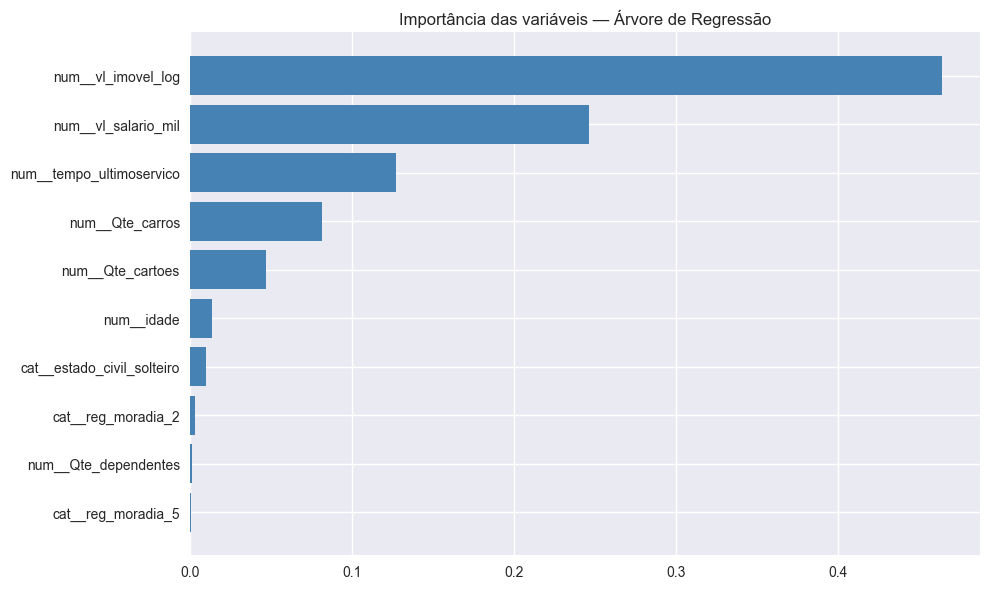

In [22]:
plt.figure(figsize=(10, 6))
top = importancias.head(10).sort_values("Importancia")
plt.barh(top["Variavel"], top["Importancia"], color="steelblue")
plt.title("Importância das variáveis — Árvore de Regressão")
plt.tight_layout()
plt.show()

### Comparação final

In [23]:
resultado = pd.DataFrame({
    "Modelo": ["Regressao Linear", "Arvore (depth=8)"],
    "R2": [r2_score(y_test, pred_lr), r2_score(y_test, pred_tree)],
    "RMSE": [root_mean_squared_error(y_test, pred_lr),
             root_mean_squared_error(y_test, pred_tree)],
    "MAE": [mean_absolute_error(y_test, pred_lr),
            mean_absolute_error(y_test, pred_tree)]
})

resultado.round(4)

,Modelo,R2,RMSE,MAE
0,Regressao Linear,0.6203,81.5714,62.3233
1,Arvore (depth=8),0.6301,80.5101,60.3367


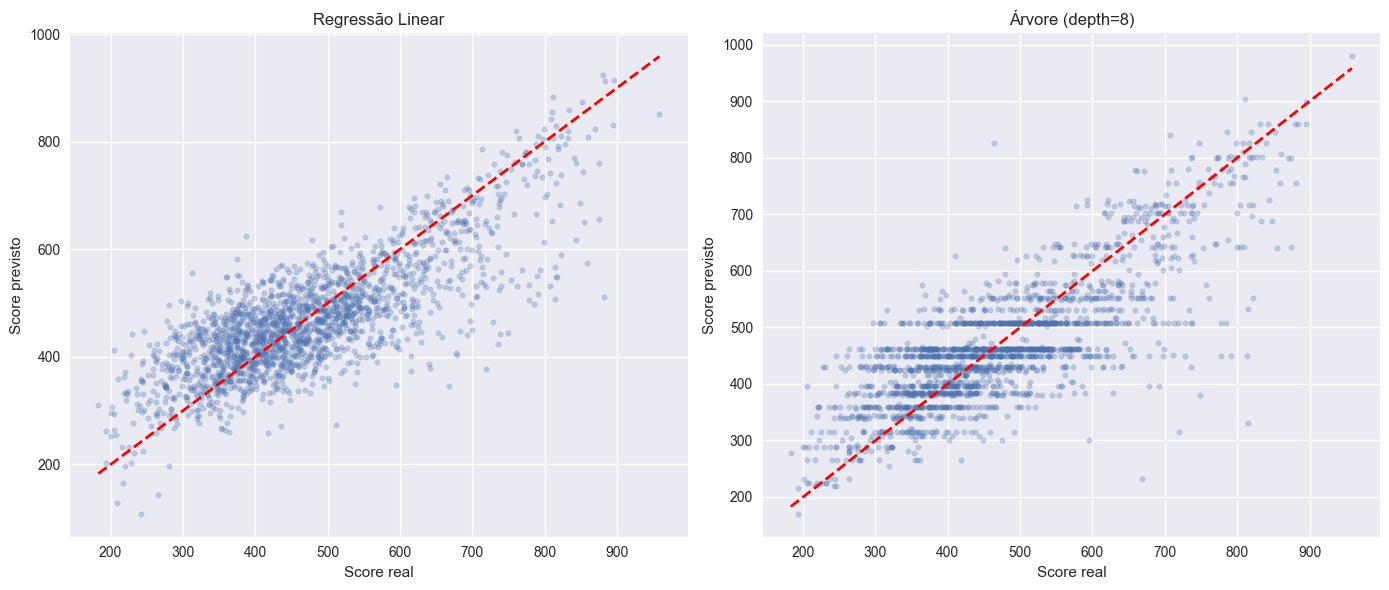

In [24]:
# Previsto vs. Real — qualidade visual dos dois modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pred, titulo in [(axes[0], pred_lr, "Regressão Linear"),
                          (axes[1], pred_tree, "Árvore (depth=8)")]:
    ax.scatter(y_test, pred, alpha=0.3, s=15)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", lw=2)
    ax.set_xlabel("Score real")
    ax.set_ylabel("Score previsto")
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

## Simulador de novo cliente

In [25]:
def simular_score(idade, sexo, estado_civil, escola, qte_dependentes,
                  tempo_ultimoservico, trabalha, vl_salario_mil,
                  reg_moradia, casa_propria, vl_imovel_em_mil,
                  qte_cartoes, qte_carros):
    """Preve o SCORE_CREDITO de um novo cliente com o modelo linear."""
    novo = pd.DataFrame({
        "idade": [idade],
        "sexo": [sexo],
        "estado_civil": [estado_civil],
        "escola": [escola],
        "Qte_dependentes": [qte_dependentes],
        "tempo_ultimoservico": [tempo_ultimoservico],
        "trabalha": [trabalha],
        "vl_salario_mil": [vl_salario_mil],
        "reg_moradia": [reg_moradia],
        "casa_propria": [casa_propria],
        "Qte_cartoes": [qte_cartoes],
        "Qte_carros": [qte_carros],
        "vl_imovel_log": [np.log1p(vl_imovel_em_mil)]
    })
    return modelo_lr.predict(novo)[0]

score = simular_score(
    idade=40, sexo="M", estado_civil="casado", escola="graduacao",
    qte_dependentes=2, tempo_ultimoservico=36, trabalha=1,
    vl_salario_mil=75, reg_moradia=2, casa_propria=1,
    vl_imovel_em_mil=350, qte_cartoes=2, qte_carros=1
)

print("Score previsto para o novo cliente:", round(score, 2))

Score previsto para o novo cliente: 561.73
